## Life Expectancy Prediction Using Regression

## 1. Problem Definition
### Objective

#### The objective of this project is to predict a country's life expectancy using socioeconomic and development indicators such as HDI, literacy rate, poverty rate, internet penetration, clean water access, GDP per capita, and child mortality.

### Business Problem

#### Governments and policymakers need to understand which factors influence life expectancy so they can improve healthcare, education, sanitation, and living conditions.

### Target Variable
#### y = life_expectancy_years
### Problem Type
#### Supervised Machine Learning - Regression

#### Because the target variable is continuous numerical data


### Algorithms Used:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- K-Nearest Neighbors Regressor (KNN)
- Support Vector Regressor (SVM)

### Import libraries

In [64]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Train Test Split
from sklearn.model_selection import train_test_split

# Regression Algorithms
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

#### Libraries are imported for:

- data handling
- visualization
- preprocessing
- machine learning
- evaluation

## phase-1 EDA,model evaluation and comparison

 ## 2.Data Collection & Ingestion

Dataset Source:

Dataset obtained from Kaggle

" Global Poverty and Economic Inequality Dataset " 

In [65]:
df = pd.read_csv("global_poverty_economic_inequality.csv")

In [66]:
print(df.info()) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   record_id                       10000 non-null  object 
 1   year                            10000 non-null  int64  
 2   country                         10000 non-null  object 
 3   region                          10000 non-null  object 
 4   income_group                    10000 non-null  object 
 5   gdp_per_capita_usd              10000 non-null  int64  
 6   poverty_rate_pct                10000 non-null  float64
 7   gini_coefficient                10000 non-null  float64
 8   hdi_score                       10000 non-null  float64
 9   unemployment_rate_pct           10000 non-null  float64
 10  inflation_rate_pct              10000 non-null  float64
 11  literacy_rate_pct               10000 non-null  float64
 12  life_expectancy_years           1

In [67]:
print(df.shape)

(10000, 25)


#### Findings
Total Rows: 10000

Total Columns: 25

Target Variable: life_expectancy_years

Numerical Features: 21

Categorical Features: 4

In [68]:
df.head()

,record_id,year,country,region,income_group,gdp_per_capita_usd,poverty_rate_pct,gini_coefficient,hdi_score,unemployment_rate_pct,...,clean_water_access_pct,internet_penetration_pct,female_labor_participation_pct,social_protection_coverage_pct,income_share_top10_pct,income_share_bottom40_pct,urban_population_pct,remittances_pct_of_gdp,foreign_aid_million_usd,co2_per_capita_tonnes
0,POV0000001,2017,Bangladesh,South Asia,Lower-Middle Income,2985,23.19,39.22,0.692,5.46,...,86.1,60.7,13.3,40.0,46.5,10.5,58.4,5.8,124,1.78
1,POV0000002,2017,Cambodia,Southeast Asia,Lower-Middle Income,1651,36.72,34.04,0.690,7.01,...,85.1,39.9,44.8,43.1,47.9,17.7,34.4,12.8,28,1.49
2,POV0000003,2019,Tanzania,Sub-Saharan Africa,Low Income,1396,72.25,40.07,0.515,5.13,...,54.0,30.6,74.9,14.0,27.0,8.0,37.7,15.5,257,0.54
3,POV0000004,2022,Myanmar,Southeast Asia,Lower-Middle Income,1304,14.46,36.31,0.661,11.96,...,71.7,34.0,59.8,44.7,55.0,16.8,44.4,7.8,196,1.00
4,POV0000005,2017,Tanzania,Sub-Saharan Africa,Low Income,1290,41.03,44.10,0.412,6.98,...,55.2,10.5,54.3,24.7,45.2,15.6,25.5,24.6,946,0.49


In [69]:
df.describe()

,year,gdp_per_capita_usd,poverty_rate_pct,gini_coefficient,hdi_score,unemployment_rate_pct,inflation_rate_pct,literacy_rate_pct,life_expectancy_years,child_mortality_per_1000,...,clean_water_access_pct,internet_penetration_pct,female_labor_participation_pct,social_protection_coverage_pct,income_share_top10_pct,income_share_bottom40_pct,urban_population_pct,remittances_pct_of_gdp,foreign_aid_million_usd,co2_per_capita_tonnes
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2020.113500,13365.287600,22.881256,42.139246,0.656249,8.965726,10.112306,73.955290,69.55495,36.769500,...,74.716140,54.824540,53.164850,39.502570,40.017980,14.993200,52.265010,7.052740,159.121800,3.901968
std,2.708865,22003.606806,20.620316,7.628379,0.162896,3.770972,8.062916,17.789112,8.34909,31.345278,...,19.550464,25.822714,16.765984,23.854333,8.656358,4.040707,21.662953,6.383465,295.693218,4.601258
min,2015.000000,470.000000,0.500000,20.300000,0.352000,-1.020000,-2.910000,35.100000,52.00000,1.500000,...,30.000000,5.000000,5.500000,5.000000,25.000000,8.000000,15.000000,0.000000,0.000000,0.100000
25%,2018.000000,1518.000000,4.787500,36.740000,0.535000,6.120000,4.720000,60.400000,63.80000,10.400000,...,61.700000,32.900000,44.900000,19.975000,32.500000,11.500000,34.400000,1.800000,13.000000,0.700000
50%,2020.000000,2920.000000,16.980000,42.075000,0.649000,8.640000,8.160000,74.900000,69.50000,29.400000,...,78.900000,53.600000,58.000000,35.300000,40.200000,15.000000,50.000000,4.800000,61.000000,2.140000
75%,2022.000000,11478.250000,35.692500,47.912500,0.759000,11.530000,11.870000,89.800000,75.70000,53.500000,...,91.200000,74.400000,65.900000,57.000000,47.500000,18.500000,71.500000,11.400000,176.000000,5.530000
max,2024.000000,107221.000000,74.870000,63.510000,0.990000,21.310000,38.770000,99.900000,86.30000,119.700000,...,100.000000,99.000000,83.200000,95.000000,55.000000,22.000000,95.000000,25.000000,6213.000000,19.980000


In [70]:
print(df.isnull().sum())

record_id                         0
year                              0
country                           0
region                            0
income_group                      0
gdp_per_capita_usd                0
poverty_rate_pct                  0
gini_coefficient                  0
hdi_score                         0
unemployment_rate_pct             0
inflation_rate_pct                0
literacy_rate_pct                 0
life_expectancy_years             0
child_mortality_per_1000          0
electricity_access_pct            0
clean_water_access_pct            0
internet_penetration_pct          0
female_labor_participation_pct    0
social_protection_coverage_pct    0
income_share_top10_pct            0
income_share_bottom40_pct         0
urban_population_pct              0
remittances_pct_of_gdp            0
foreign_aid_million_usd           0
co2_per_capita_tonnes             0
dtype: int64


## 3. Exploratory Data Analysis (EDA)

### Target Variable Distribution

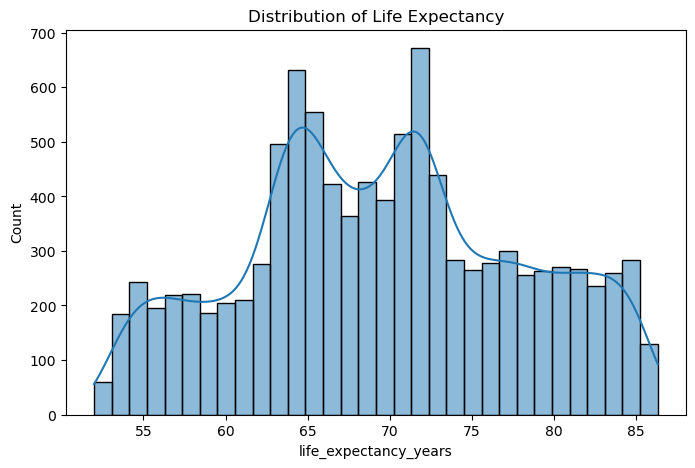

In [71]:
plt.figure(figsize=(8,5))
sns.histplot(df['life_expectancy_years'], kde=True)
plt.title('Distribution of Life Expectancy')
plt.show()

### Insight
- Life expectancy values are distributed between approximately 50–85 years.
- Most countries fall within the middle range.
- No severe skewness is observed.

### Boxplot for Outlier Detection

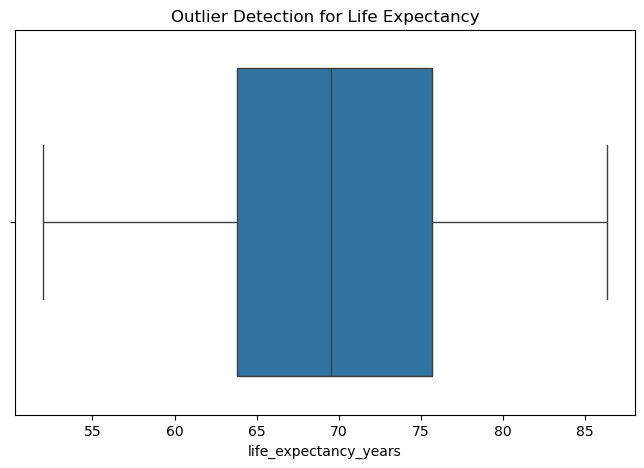

In [72]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['life_expectancy_years'])
plt.title('Outlier Detection for Life Expectancy')
plt.show()

#### Insight
- Helps identify unusually low or high life expectancy values.
- Outliers may represent countries with extreme socioeconomic conditions.
  
in this there is no outliers

### HDI vs Life Expectancy

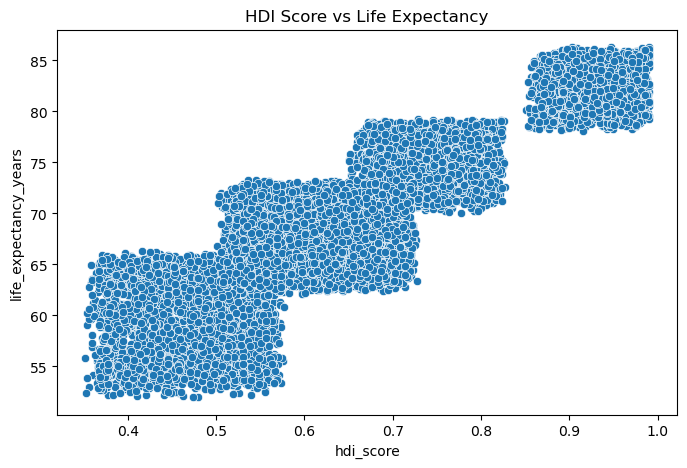

In [73]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='hdi_score',
    y='life_expectancy_years',
    data=df
)

plt.title("HDI Score vs Life Expectancy")

plt.show()

#### Insight
- Strong positive relationship observed.
- Countries with higher HDI generally have higher life expectancy.

### Poverty Rate vs Life Expectancy

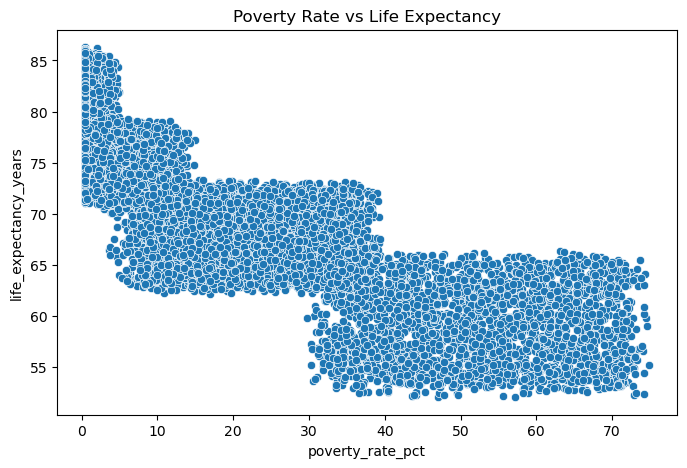

In [74]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='poverty_rate_pct', y='life_expectancy_years', data=df)
plt.title('Poverty Rate vs Life Expectancy')
plt.show()

#### Insight
- Negative relationship observed.
- Higher poverty levels tend to reduce life expectancy.

### Child Mortality vs Life Expectancy

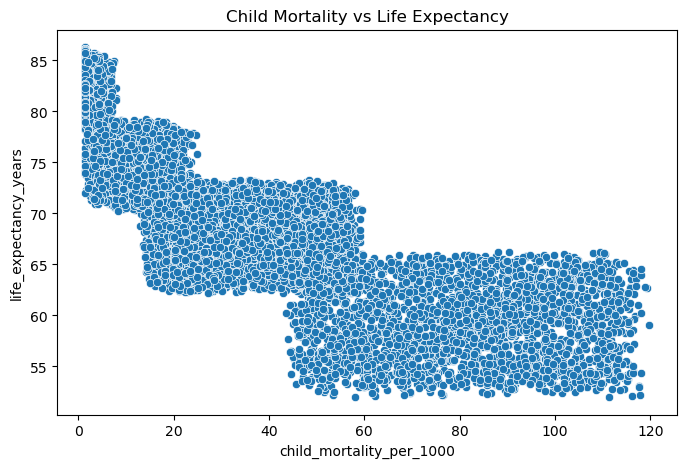

In [75]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='child_mortality_per_1000', y='life_expectancy_years', data=df)
plt.title('Child Mortality vs Life Expectancy')
plt.show()

#### Insight
- Strong negative relationship.
- Countries with higher child mortality generally have lower life expectancy.

### Top Features Affecting Life Expectancy

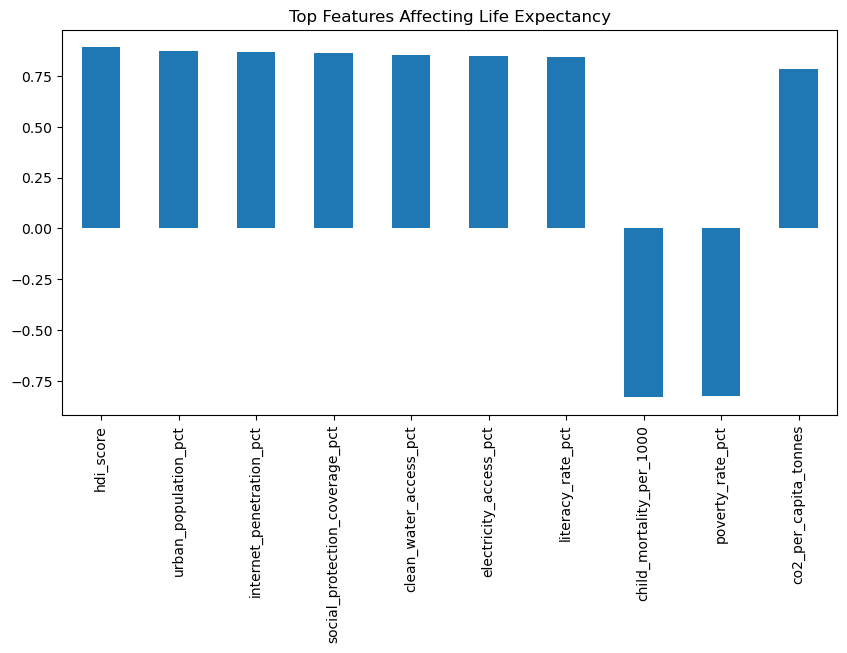

In [76]:
correlation = df.corr(numeric_only=True)['life_expectancy_years']

top_corr = correlation.drop('life_expectancy_years').sort_values(
    key=abs, ascending=False
)[:10]

plt.figure(figsize=(10,5))
top_corr.plot(kind='bar')
plt.title('Top Features Affecting Life Expectancy')
plt.show()

#### Insight
- HDI score, literacy rate, internet penetration, and urban population are strong predictors.
- Poverty rate and child mortality negatively affect life expectancy.

### Encode Categorical Columns

In [77]:
label_encoder = LabelEncoder()
categorical_columns = ['country', 'region', 'income_group']
for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

#### Insights
- Machine learning models cannot process text directly.
- Encoding converts text into numeric values.

In [78]:
#remove unnesccessary coulunms
df = df.drop('record_id', axis=1)

### Heatmap
Heatmap shows relationships between variables.

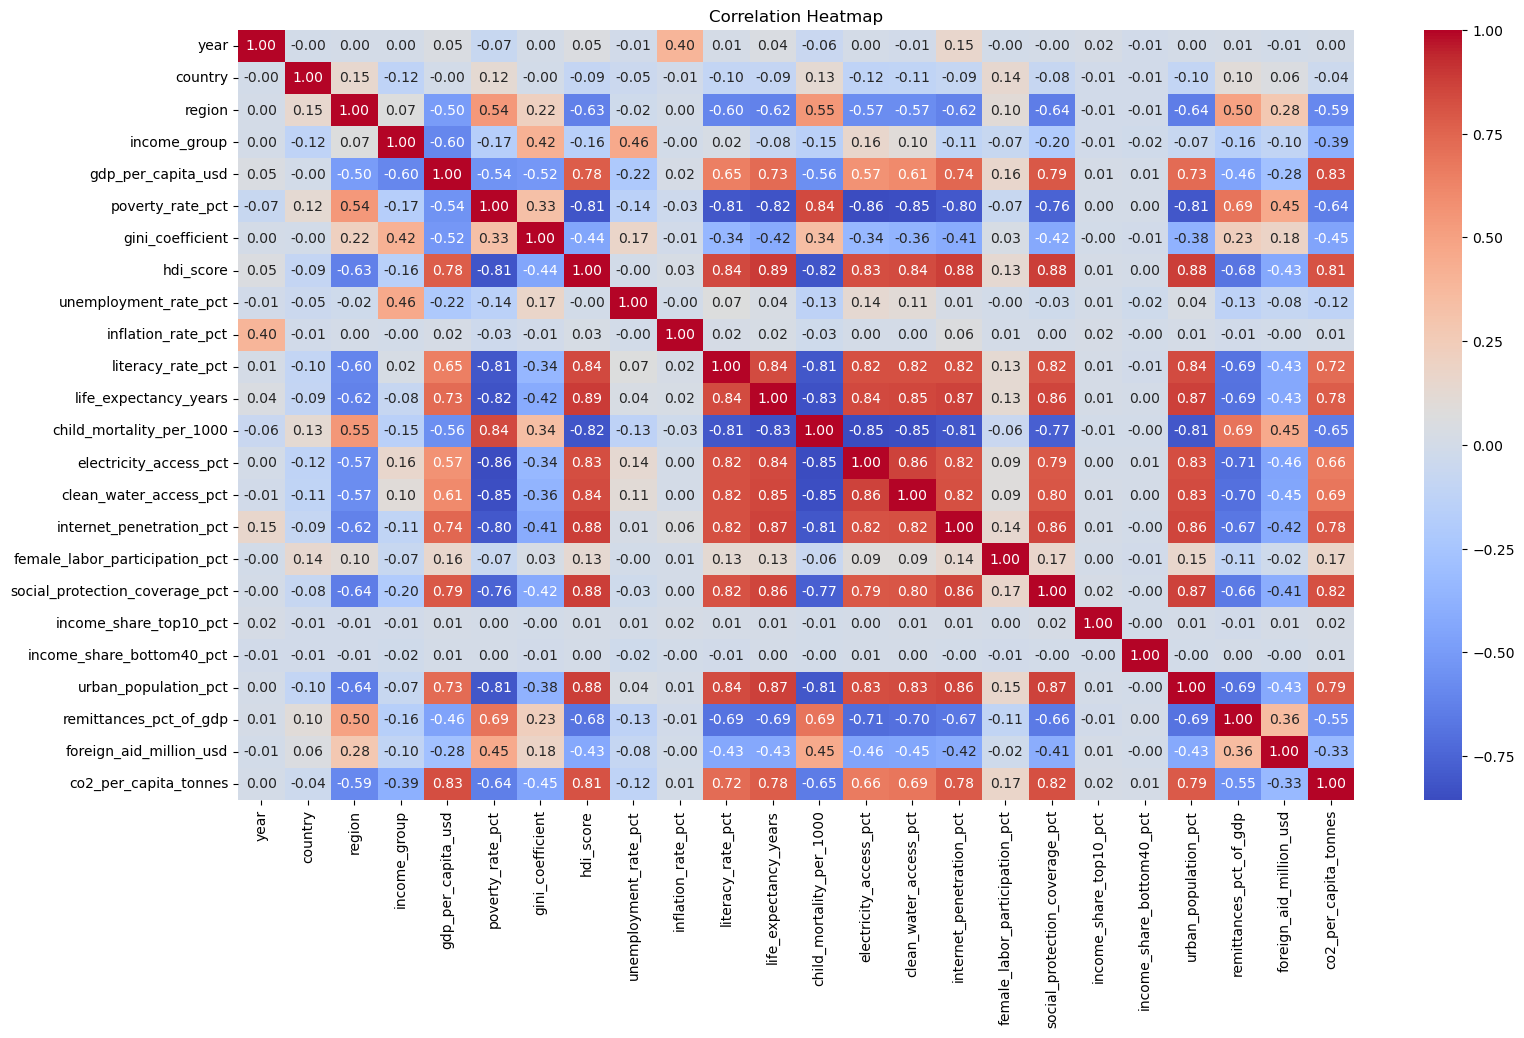

In [79]:
plt.figure(figsize=(18,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

#### Insight
#### Strong Positive Features
- hdi_score
- literacy_rate_pct
- urban_population_pct
- internet_penetration_pct
- clean_water_access_pct

These increase life expectancy.

#### Strong Negative Features
- poverty_rate_pct
- child_mortality_per_1000

These reduce life expectancy.

In [80]:
correlation = df.corr()['life_expectancy_years']

print(correlation.sort_values(ascending=False))

life_expectancy_years             1.000000
hdi_score                         0.888430
urban_population_pct              0.869628
internet_penetration_pct          0.867733
social_protection_coverage_pct    0.860892
clean_water_access_pct            0.848720
electricity_access_pct            0.844587
literacy_rate_pct                 0.839171
co2_per_capita_tonnes             0.780730
gdp_per_capita_usd                0.731209
female_labor_participation_pct    0.126370
year                              0.044610
unemployment_rate_pct             0.035902
inflation_rate_pct                0.024195
income_share_top10_pct            0.011193
income_share_bottom40_pct         0.003360
income_group                     -0.075178
country                          -0.091132
gini_coefficient                 -0.415926
foreign_aid_million_usd          -0.432760
region                           -0.618802
remittances_pct_of_gdp           -0.691393
poverty_rate_pct                 -0.824163
child_morta

### Feature Selection

Only highly relevant features are selected for prediction.

Feature selection helps improve model performance, reduce overfitting, and simplify the model by removing weak or irrelevant variables.

In [81]:
selected_features = [

    'hdi_score',
    'urban_population_pct',
    'internet_penetration_pct',
    'social_protection_coverage_pct',
    'clean_water_access_pct',
    'electricity_access_pct',
    'literacy_rate_pct',
    'gdp_per_capita_usd',
    'poverty_rate_pct',
    'child_mortality_per_1000'
]

X = df[selected_features]

y = df['life_expectancy_years']

#### Insight

Feature selection:

- improves model accuracy
- reduces overfitting
- removes weak predictors

  
Only strongly related features are selected.  

## 4. Model Selection & Comparison

### Train-Test Split

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [83]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

#### Feature scaling standardizes numerical values using StandardScaler. This is important because features have different ranges. Scaling is especially important for distance-based algorithms such as KNN and SVR.

### Linear Regression

Linear Regression is trained as a baseline regression model. It predicts life expectancy by assuming a linear relationship between the input features and the target variable

In [84]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

### Decision Tree Regressor

Decision Tree Regressor predicts values by creating tree-like decision structures. It can capture nonlinear relationships but may overfit the training data if not controlled properly.

In [85]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)

### Random Forest Regressor

Random Forest Regressor combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is an ensemble learning method and generally performs better than a single decision tree.-+

In [86]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

### KNN Regressor

KNN Regressor predicts life expectancy based on nearby similar data points. Countries with similar socioeconomic conditions are expected to have similar life expectancy values.

In [87]:
knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

### SVM Regressor

Support Vector Regressor (SVR) predicts continuous numerical values by finding optimal prediction boundaries. It is effective for capturing nonlinear relationships between variables.

In [88]:
svm = SVR()

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

### Evaluate Models

#### Regression models are evaluated using:

- R² Score
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)

Higher R² scores and lower MAE/MSE values indicate better model performance.

In [89]:
models = {

    'Linear Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'KNN Regressor': y_pred_knn,
    'SVM Regressor': y_pred_svm
}

for name, prediction in models.items():

    print("\n", name)

    print("R2 Score:",
          r2_score(y_test, prediction))

    print("MAE:",
          mean_absolute_error(y_test, prediction))

    print("MSE:",
          mean_squared_error(y_test, prediction))


 Linear Regression
R2 Score: 0.8620080092298
MAE: 2.559714929142538
MSE: 9.367244155748129

 Decision Tree
R2 Score: 0.7509270449715344
MAE: 3.276
MSE: 16.907700000000006

 Random Forest
R2 Score: 0.8683122347134938
MAE: 2.5135045
MSE: 8.939297439500002

 KNN Regressor
R2 Score: 0.8524577739329136
MAE: 2.60995
MSE: 10.015538199999998

 SVM Regressor
R2 Score: 0.8689810157732815
MAE: 2.5079853528868177
MSE: 8.89389889543375


## Model-Wise Insights
#### 1. Linear Regression
 - R² = 0.862
 - Linear Regression captured most relationships effectively.
 - many features have linear relationships with life expectancy

#### 2. Decision Tree Regressor
- Lowest R² = 0.751
- Highest MAE and MSE
- Decision Tree performed worst among all models.


#### 3. Random Forest Regressor
- R² = 0.868
- Very low error values
- Random Forest performed extremely well.

#### 4. KNN Regressor
- R² = 0.852
- KNN achieved good results after feature scaling.
- Reason:
  - countries with similar economic and social indicators tend to have similar life expectancy

#### 5. SVM Regressor
- Best R² = 0.869
- Lowest MSE = 8.89
- SVM Regressor achieved the best overall performance.


### This indicates:

- life expectancy relationships are not completely linear
- the best model is SVR


### Feature importance

Feature importance analysis identifies which variables contribute most to prediction. Random Forest feature importance is used to determine the most influential socioeconomic indicators affecting life expectancy.

In [92]:
importance = pd.DataFrame({

    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                          Feature  Importance
7              gdp_per_capita_usd    0.751838
0                       hdi_score    0.064579
5          electricity_access_pct    0.050750
8                poverty_rate_pct    0.043968
4          clean_water_access_pct    0.025353
1            urban_population_pct    0.013340
9        child_mortality_per_1000    0.013088
2        internet_penetration_pct    0.012536
3  social_protection_coverage_pct    0.012439
6               literacy_rate_pct    0.012109


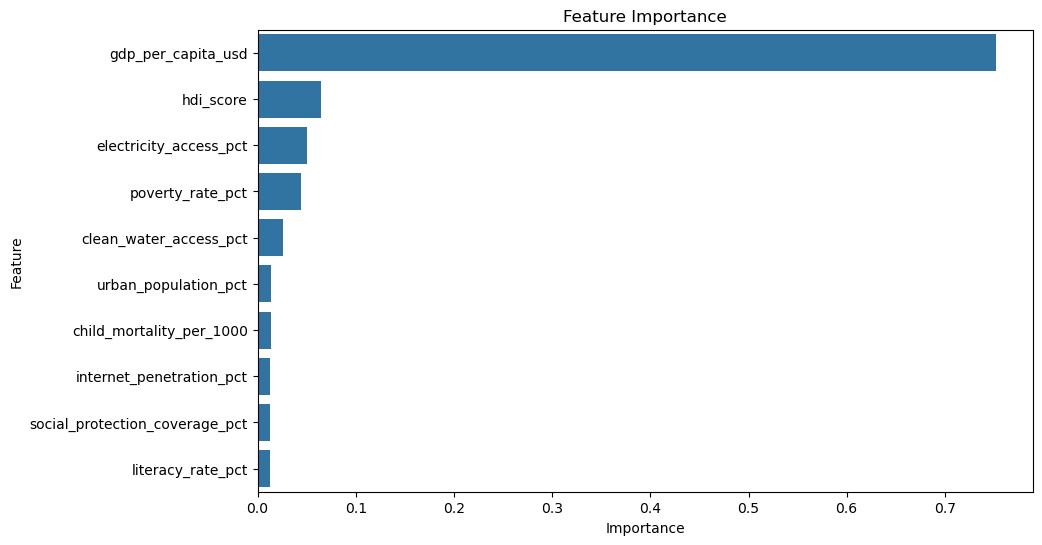

In [91]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()

### Hyperparameter Tuning

Hyperparameter tuning is performed using GridSearchCV to identify the best parameter values for  SVR models. This improves model performance and generalization.

In [93]:
# Hyperparameter Grid
svr_params = {
    'kernel': ['rbf'],
    'C': [1, 10],
    'epsilon': [0.1],
    'gamma': ['scale']
}

In [94]:
# # GridSearchCV
svr_grid = GridSearchCV(
    estimator=svm,
    param_grid=svr_params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

In [95]:
# # Train Tuned Model
svr_grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=3, estimator=SVR(), n_jobs=-1,
             param_grid={'C': [1, 10], 'epsilon': [0.1], 'gamma': ['scale'],
                         'kernel': ['rbf']},
             scoring='r2')

In [96]:
# Best Parameters
print(svr_grid.best_params_)

{'C': 1, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}


In [97]:
# Best SVR Model
best_svr = svr_grid.best_estimator_
# Tuned SVR Prediction
svr_pred = best_svr.predict(X_test_scaled)

In [98]:
# Tuned SVR Evaluation
print("R2 Score:")
print(r2_score(y_test, svr_pred))

R2 Score:
0.8689810157732815


### Prediction

The trained model predicts life expectancy values for the testing dataset. These predictions are compared with actual values to evaluate model accuracy.

In [99]:
predictions = best_svr.predict(X_test_scaled)

print(predictions[:1])

[75.54301506]


### Actual vs Predicted

A comparison table is created to compare actual and predicted life expectancy values. Smaller differences between actual and predicted values indicate better model performance.

In [100]:
comparison = pd.DataFrame({

    'Actual': y_test.values,
    'Predicted': predictions
})

print(comparison.head(10))

   Actual  Predicted
0    75.9  75.543015
1    85.1  82.691334
2    64.8  67.331989
3    71.9  66.618482
4    73.4  74.829051
5    63.7  67.753835
6    82.4  83.056994
7    64.2  67.299749
8    67.5  67.540560
9    61.8  60.205704


### Actual vs Predicted Visualization

A scatter plot is created to visualize the relationship between actual and predicted life expectancy values. Points closer to the diagonal line indicate more accurate predictions.

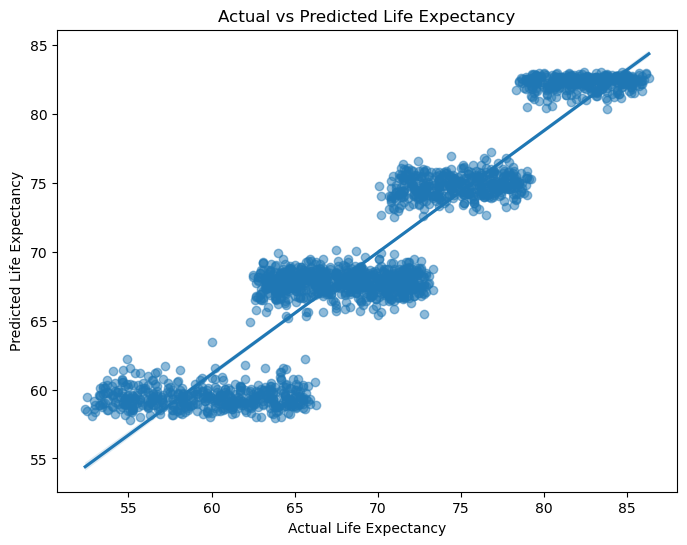

In [101]:
plt.figure(figsize=(8,6))

sns.regplot(
    x=y_test,
    y=predictions,
    scatter_kws={'alpha':0.5}
)

plt.xlabel("Actual Life Expectancy")

plt.ylabel("Predicted Life Expectancy")

plt.title("Actual vs Predicted Life Expectancy")

plt.show()

### insights:

The Actual vs Predicted visualization showed that the model successfully captured overall life expectancy patterns across countries. Countries were grouped into distinct life expectancy ranges, reflecting differences in economic development and living standards. The SVM model produced stable and accurate predictions with minimal error, indicating that socioeconomic and development indicators are strong predictors of life expectancy.

### Prediction Using Unseen Data

The trained model is used to predict life expectancy for completely new unseen data. This demonstrates how the model can be applied in real-world scenarios.

In [102]:
new_data = pd.DataFrame({

    'hdi_score': [0.82],
    'urban_population_pct': [72],
    'internet_penetration_pct': [80],
    'social_protection_coverage_pct': [65],
    'clean_water_access_pct': [90],
    'electricity_access_pct': [95],
    'literacy_rate_pct': [88],
    'gdp_per_capita_usd': [15000],
    'poverty_rate_pct': [12],
    'child_mortality_per_1000': [18]
})

In [103]:
new_data_scaled = scaler.transform(new_data)

In [104]:
prediction = svm.predict(new_data_scaled)

print("Predicted Life Expectancy:", prediction[0])

Predicted Life Expectancy: 75.9626977539266


## Phase 2: Final Pipeline Integration

#### A complete machine learning pipeline was created using Scikit-Learn Pipeline and ColumnTransformer. The pipeline integrates preprocessing steps and the optimized SVR model into a single workflow, preventing data leakage and ensuring consistent preprocessing during training and prediction.The final pipeline was serialized using Joblib for deployment.

### Define Features

In [105]:
X = df.drop('life_expectancy_years', axis=1)
y = df['life_expectancy_years']

### Group Features

In [106]:
# Numerical Features
numerical_features = [
    'hdi_score',
    'urban_population_pct',
    'internet_penetration_pct',
    'social_protection_coverage_pct',
    'clean_water_access_pct',
    'electricity_access_pct',
    'literacy_rate_pct',
    'gdp_per_capita_usd',
    'poverty_rate_pct',
    'child_mortality_per_1000'
]

In [107]:
# Categorical Features
categorical_features = [
    'country',
    'region',
    'income_group'
]

In [108]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

### Numerical Pipeline

In [109]:
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]
)

## Combine Transformers

In [110]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features)
    ]
)

## Build Final Pipeline

In [111]:
from sklearn.svm import SVR
final_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', SVR(
            C=10,
            kernel='rbf',
            gamma='scale'
        ))
    ]
)

In [112]:
final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['hdi_score',
                                                   'urban_population_pct',
                                                   'internet_penetration_pct',
                                                   'social_protection_coverage_pct',
                                                   'clean_water_access_pct',
                                                   'electricity_access_pct',
                                                   'literacy_rate_pct',
                                                   'gdp_per_capita_usd',
                                                   'poverty_rate_pct',
                                                   'child_mortality_per_1000'])])),
                ('model', SVR(C=10))])

### Evaluate Pipeline

In [113]:
from sklearn.metrics import r2_score

predictions = final_pipeline.predict(X_test)

print("R2 Score:",
      r2_score(y_test, predictions))

R2 Score: 0.8676881931694833


### Export Pipeline

In [114]:
import joblib
joblib.dump(
    final_pipeline,
    "life_expectancy_pipeline.pkl"
)

['life_expectancy_pipeline.pkl']

### Verify Saved Model

In [115]:
loaded_pipeline = joblib.load(
    "life_expectancy_pipeline.pkl"
)

In [116]:
loaded_pipeline.predict(X_test.head(1))

array([75.5008801])

## phase-3 Streamlit Deployment

A Streamlit web application was developed to make the machine learning model accessible to end users. The saved pipeline file was loaded directly into the application, allowing raw user inputs to be processed automatically through the same preprocessing and prediction workflow used during training. Interactive widgets such as sliders and input boxes were used to collect feature values, and the application generated real-time life expectancy predictions instantly.

## Conclusion

This project successfully developed a machine learning model to predict life expectancy years using socioeconomic and development indicators. The dataset was analyzed through Exploratory Data Analysis (EDA), where relationships between features and the target variable were identified using statistical summaries, visualizations, and correlation analysis.

Data preprocessing techniques such as handling missing values, encoding categorical variables, feature scaling, and feature selection were applied to prepare the dataset for modeling. Multiple regression algorithms including Linear Regression, Decision Tree Regressor, Random Forest Regressor, KNN Regressor, and Support Vector Regressor (SVR) were trained and evaluated.

Based on performance metrics such as R² Score, MAE, and MSE, the SVR model achieved the best overall performance with an R² score of approximately 0.869, indicating strong predictive capability. The analysis also revealed that factors such as HDI score, literacy rate, internet penetration, clean water access, and GDP per capita positively influence life expectancy, while poverty rate and child mortality have a negative impact.

To make the solution production-ready, a complete machine learning pipeline was created to automate preprocessing and prediction steps, preventing data leakage and ensuring consistency. The final pipeline was exported using Joblib and deployed through a Streamlit web application, allowing users to input raw socioeconomic indicators and receive real-time life expectancy predictions.